# Lekcja 12: Pandas II - Transformacje i Grupowanie

# 1. GroupBy - Podstawy Grupowania Danych

In [5]:
# Przykład 1: Podstawowe Grupowanie - Titanic Dataset

# Wczytanie datasetu Titanic
import pandas as pd
import numpy as np

# Wczytujemy dane Titanic
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

# Sprawdzamy strukturę danych
# print(titanic.head())
print(f"\nWymiary: {titanic.shape}")
print(f"\nKolumny: {titanic.columns.tolist()}")

# PODSTAWOWE GRUPOWANIE
# Średni wiek według klasy podróży
sredni_wiek_klasa = titanic.groupby('Pclass')['Age'].mean()
print("\n=== Średni wiek według klasy ===")
print(sredni_wiek_klasa)

# Interpretacja:
# - Pierwsza klasa: pasażerowie starsi (wyższy status społeczny)
# - Trzecia klasa: pasażerowie młodsi (imigranci, robotnicy)


Wymiary: (891, 12)

Kolumny: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

=== Średni wiek według klasy ===
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


In [17]:
# Przykład 2: Grupowanie po Wielu Kolumnach

# Grupowanie według dwóch zmiennych: klasy i płci
# Obliczamy współczynnik przeżycia (survival rate)
survival_grouped = titanic.groupby(['Pclass', 'Sex'])['Survived'].agg([
    'count',  # liczba pasażerów
    'sum',    # liczba ocalonych
    'mean'    # survival rate (%)
])

# Zmieniamy nazwy kolumn dla czytelności
survival_grouped.columns = ['Liczba_pasażerów', 'Liczba_ocalonych', 'Współczynnik_przeżycia']

# Formatujemy współczynnik jako procent
survival_grouped['Współczynnik_przeżycia_%'] = (survival_grouped['Współczynnik_przeżycia'] * 100).round(2)
print("\n\n=== Współczynnik przeżycia według klasy i płci ===")
print(survival_grouped)

# OBSERWACJE:
# - Kobiety miały znacznie wyższy survival rate niż mężczyźni ("kobiety i dzieci najpierw")
# - Pierwsza klasa miała lepsze szanse przeżycia
# - Najmniejsze szanse: mężczyźni z trzeciej klasy



=== Współczynnik przeżycia według klasy i płci ===
               Liczba_pasażerów  Liczba_ocalonych  Współczynnik_przeżycia  \
Pclass Sex                                                                  
1      female                94                91                0.968085   
       male                 122                45                0.368852   
2      female                76                70                0.921053   
       male                 108                17                0.157407   
3      female               144                72                0.500000   
       male                 347                47                0.135447   

               Współczynnik_przeżycia_%  
Pclass Sex                               
1      female                     96.81  
       male                       36.89  
2      female                     92.11  
       male                       15.74  
3      female                     50.00  
       male                       13

In [18]:
# Przykład 3: Zaawansowane Agregacje z .agg()

# WIELOFUNKCYJNE AGREGACJE
# Różne statystyki dla różnych kolumn jednocześnie
age_fare_stats = titanic.groupby('Pclass').agg({
    'Age': ['mean', 'median', 'std', 'min', 'max'],
    'Fare': ['mean', 'median', 'std'],
    'Survived': ['sum', 'mean']
})

print("=== Statystyki wieku i opłaty według klasy ===")
print(age_fare_stats)

# Spłaszczamy MultiIndex kolumn dla wygody
age_fare_stats.columns = ['_'.join(col).strip() for col in age_fare_stats.columns.values]
age_fare_stats = age_fare_stats.reset_index()

print("\n=== Po spłaszczeniu ===")
print(age_fare_stats)


=== Statystyki wieku i opłaty według klasy ===
              Age                                     Fare           \
             mean median        std   min   max       mean   median   
Pclass                                                                
1       38.233441   37.0  14.802856  0.92  80.0  84.154687  60.2875   
2       29.877630   29.0  14.001077  0.67  70.0  20.662183  14.2500   
3       25.140620   24.0  12.495398  0.42  74.0  13.675550   8.0500   

                  Survived            
              std      sum      mean  
Pclass                                
1       78.380373      136  0.629630  
2       13.417399       87  0.472826  
3       11.778142      119  0.242363  

=== Po spłaszczeniu ===
   Pclass   Age_mean  Age_median    Age_std  Age_min  Age_max  Fare_mean  \
0       1  38.233441        37.0  14.802856     0.92     80.0  84.154687   
1       2  29.877630        29.0  14.001077     0.67     70.0  20.662183   
2       3  25.140620        24.0  12.49

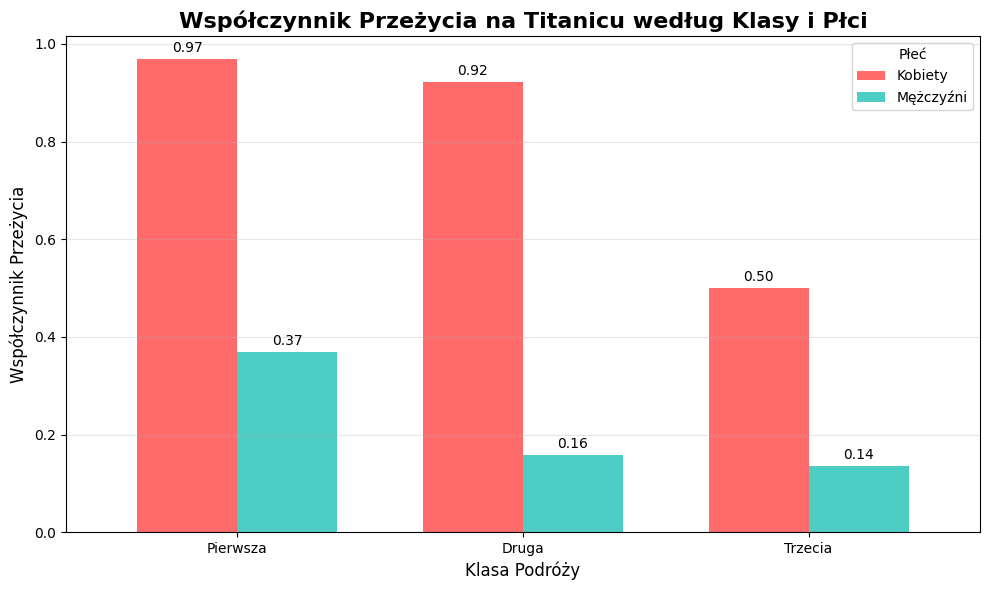

In [20]:
# Wizualizacja: Survival Rate według Klasy i Płci

import matplotlib.pyplot as plt
import seaborn as sns

# Przygotowanie danych do wykresu
survival_pivot = titanic.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

# Wykres słupkowy grupowany
fig, ax = plt.subplots(figsize=(10, 6))
survival_pivot.plot(kind='bar', ax=ax, color=['#ff6b6b', '#4ecdc4'], width=0.7)
ax.set_title('Współczynnik Przeżycia na Titanicu według Klasy i Płci', fontsize=16, fontweight='bold')
ax.set_xlabel('Klasa Podróży', fontsize=12)
ax.set_ylabel('Współczynnik Przeżycia', fontsize=12)
ax.set_xticklabels(['Pierwsza', 'Druga', 'Trzecia'], rotation=0)
ax.legend(title='Płeć', labels=['Kobiety', 'Mężczyźni'])
ax.grid(axis='y', alpha=0.3)

# Dodajemy etykiety z wartościami
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()

# INTERPRETACJA:
# - Kobiety z 1. i 2. klasy: ~95% survival rate
# - Mężczyźni z 3. klasy: ~13% survival rate
# - Widoczna jest zarówno klasowa, jak i płciowa dysproporcja w szansach przeżycia

# 2. Funkcje Agregujące i Transform

In [6]:
# Przykład 1: Aggregation vs Transform

# Wczytujemy dane o sprzedaży (symulowane)
np.random.seed(42)
sales_data = pd.DataFrame({
    'Region': np.random.choice(['Północ', 'Południe', 'Wschód', 'Zachód'], 200),
    'Produkt': np.random.choice(['A', 'B', 'C'], 200),
    'Sprzedaż': np.random.randint(100, 1000, 200),
    'Koszt': np.random.randint(50, 500, 200)
})
print(sales_data.head(10))

# AGGREGATION - zwraca jedną wartość na grupę
avg_sales_region = sales_data.groupby('Region')['Sprzedaż'].mean()
print("\n=== Średnia sprzedaż według regionu (Aggregation) ===")
print(avg_sales_region)
print(f"Rozmiar wyniku: {avg_sales_region.shape}")  # (4,) - 4 regiony

# TRANSFORM - zwraca wartość dla każdego wiersza
sales_data['Średnia_region'] = sales_data.groupby('Region')['Sprzedaż'].transform('mean')
print("\n=== DataFrame z dodaną kolumną Transform ===")
print(sales_data.head(10))
print(f"Rozmiar wyniku: {sales_data.shape}")  # (200, 5) - oryginalny rozmiar zachowany!

# Każdy wiersz ma przypisaną średnią swojego regionu
# To umożliwia porównanie konkretnej obserwacji z grupową średnią

     Region Produkt  Sprzedaż  Koszt
0    Wschód       C       596    317
1    Zachód       C       401    372
2    Północ       A       280    114
3    Wschód       A       706    466
4    Wschód       B       198    217
5    Zachód       A       799    379
6    Północ       C       215     92
7    Północ       C       290     93
8    Wschód       A       352    334
9  Południe       C       260    446

=== Średnia sprzedaż według regionu (Aggregation) ===
Region
Południe    548.760870
Północ      564.304348
Wschód      595.222222
Zachód      595.851852
Name: Sprzedaż, dtype: float64
Rozmiar wyniku: (4,)

=== DataFrame z dodaną kolumną Transform ===
     Region Produkt  Sprzedaż  Koszt  Średnia_region
0    Wschód       C       596    317      595.222222
1    Zachód       C       401    372      595.851852
2    Północ       A       280    114      564.304348
3    Wschód       A       706    466      595.222222
4    Wschód       B       198    217      595.222222
5    Zachód       A    

In [23]:
# Przykład 2: Standaryzacja Grupowa z Transform

# STANDARYZACJA WEDŁUG GRUPY
# Normalizujemy sprzedaż wewnątrz każdego regionu (z-score)

def standaryzacja(x):
    """Standaryzacja: (x - mean) / std"""
    return (x - x.mean()) / x.std()

# Standaryzacja sprzedaży według regionu
sales_data['Sprzedaż_std_region'] = sales_data.groupby('Region')['Sprzedaż'].transform(standaryzacja)

# Sprawdzamy wyniki dla regionu 'Północ'
polnoc = sales_data[sales_data['Region'] == 'Północ'][['Region', 'Sprzedaż', 'Sprzedaż_std_region']].head(10)
print("\n=== Standaryzacja sprzedaży w regionie Północ ===")
print(polnoc)

# Weryfikacja: średnia standaryzowanych wartości w grupie powinna być ~0, std ~1
print("\n=== Weryfikacja standaryzacji ===")
verification = sales_data.groupby('Region')['Sprzedaż_std_region'].agg(['mean', 'std'])
print(verification)

# ZASTOSOWANIE:
# - Porównanie wyników w różnych skalach (różne regiony, różne produkty)
# - Wykrywanie outliers w kontekście grupy
# - Feature engineering dla modeli ML


=== Standaryzacja sprzedaży w regionie Północ ===
    Region  Sprzedaż  Sprzedaż_std_region
2   Północ       280            -1.078252
6   Północ       215            -1.324771
7   Północ       290            -1.040326
15  Północ       834             1.022848
21  Północ       891             1.239026
30  Północ       884             1.212477
31  Północ       203            -1.370283
35  Północ       275            -1.097215
37  Północ       576             0.044357
38  Północ       781             0.821840

=== Weryfikacja standaryzacji ===
                  mean  std
Region                     
Południe  5.551115e-17  1.0
Północ   -1.490354e-16  1.0
Wschód    1.788693e-16  1.0
Zachód    4.111937e-18  1.0


In [34]:
# Przykład 3: Wypełnianie Brakujących Wartości Grupowo

# Symulujemy dane z brakami
sales_missing = sales_data.copy()

# Losowo usuwamy 20% wartości w kolumnie Sprzedaż
missing_idx = np.random.choice(sales_missing.index, size=40, replace=False)
sales_missing.loc[missing_idx, 'Sprzedaż'] = np.nan
print(f"Liczba braków: {sales_missing['Sprzedaż'].isnull().sum()}")

# WYPEŁNIANIE MEDIANĄ GRUPOWĄ
# Zamiast globalnej mediany, używamy mediany z każdego regionu
sales_missing['Sprzedaż_filled'] = sales_missing.groupby('Region')['Sprzedaż'].transform(
    lambda x: x.fillna(x.median())
)

# Porównanie: które wartości zostały wypełnione
filled_values = sales_missing[sales_missing['Sprzedaż'].isnull()][['Region', 'Sprzedaż', 'Sprzedaż_filled']].head(10)
print("\n=== Wypełnione wartości (braki zastąpione medianą regionu) ===")
print(filled_values)

# Sprawdzamy, czy braki zostały usunięte
print(f"\nLiczba braków po wypełnieniu: {sales_missing['Sprzedaż_filled'].isnull().sum()}")

Liczba braków: 40

=== Wypełnione wartości (braki zastąpione medianą regionu) ===
      Region  Sprzedaż  Sprzedaż_filled
0     Wschód       NaN            618.0
1     Zachód       NaN            624.0
18    Zachód       NaN            624.0
20  Południe       NaN            573.0
21    Północ       NaN            549.0
22  Południe       NaN            573.0
26  Południe       NaN            573.0
29    Zachód       NaN            624.0
30    Północ       NaN            549.0
32    Zachód       NaN            624.0

Liczba braków po wypełnieniu: 0


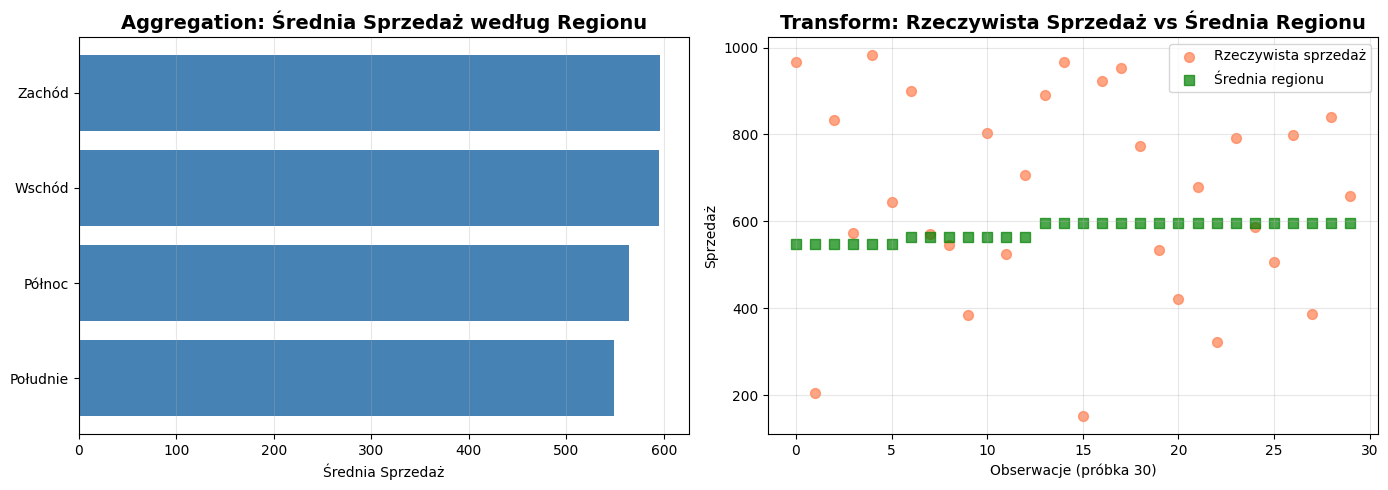

In [26]:
# Wizualizacja: Porównanie Aggregation vs Transform

# Wizualizacja różnicy między .agg() i .transform()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Aggregation - średnia według regionu
avg_sales = sales_data.groupby('Region')['Sprzedaż'].mean().sort_values()
axes[0].barh(avg_sales.index, avg_sales.values, color='steelblue')
axes[0].set_title('Aggregation: Średnia Sprzedaż według Regionu', 
fontsize=14, fontweight='bold')
axes[0].set_xlabel('Średnia Sprzedaż')
axes[0].grid(axis='x', alpha=0.3)

# Wykres 2: Transform - porównanie wartości z średnią grupową
sample_data = sales_data.sample(30).sort_values('Region')
x_pos = np.arange(len(sample_data))
axes[1].scatter(x_pos, sample_data['Sprzedaż'], label='Rzeczywista sprzedaż', s=50, alpha=0.7, color='coral')
axes[1].scatter(x_pos, sample_data['Średnia_region'], label='Średnia regionu', s=50, alpha=0.7, marker='s', color='green')
axes[1].set_title('Transform: Rzeczywista Sprzedaż vs Średnia Regionu', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Obserwacje (próbka 30)')
axes[1].set_ylabel('Sprzedaż')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 3. Feature Engineering - Tworzenie Nowych Zmiennych

In [30]:
# Przykład 1: Tworzenie Zmiennych Interakcyjnych - Titanic

# Wracamy do datasetu Titanic
titanic_fe = titanic.copy()

# === FEATURE ENGINEERING ===

# 1. Rozmiar rodziny
titanic_fe['Family_Size'] = titanic_fe['SibSp'] + titanic_fe['Parch'] + 1
# SibSp = rodzeństwo/małżonkowie, Parch = rodzice/dzieci
# +1 bo liczymy też samego pasażera

# 2. Czy podróżował sam?
titanic_fe['Is_Alone'] = (titanic_fe['Family_Size'] == 1).astype(int)

# 3. Tytuł z imienia (Mr, Mrs, Miss, Master, etc.)
titanic_fe['Title'] = titanic_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 4. Grupowanie rzadkich tytułów
title_counts = titanic_fe['Title'].value_counts()
rare_titles = title_counts[title_counts < 10].index
titanic_fe['Title'] = titanic_fe['Title'].replace(rare_titles, 'Rare')

# 5. Cena biletu na osobę w rodzinie
titanic_fe['Fare_Per_Person'] = titanic_fe['Fare'] / titanic_fe['Family_Size']
print("=== Nowe cechy ===")
print(titanic_fe[['Name', 'Family_Size', 'Is_Alone', 'Title', 'Fare', 'Fare_Per_Person']].head(10))

# Analiza: Jak rozmiar rodziny wpływa na survival rate?
survival_by_family = titanic_fe.groupby('Family_Size')['Survived'].mean()
print("\n=== Survival rate według rozmiaru rodziny ===")
print(survival_by_family)

# OBSERWACJA:
# - Osoby samotne: niższy survival rate
# - Małe rodziny (2-4): wyższy survival rate
# - Bardzo duże rodziny (5+): niższy survival rate (trudniej ewakuować dużą grupę)

=== Nowe cechy ===
                                                Name  Family_Size  Is_Alone  \
0                            Braund, Mr. Owen Harris            2         0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...            2         0   
2                             Heikkinen, Miss. Laina            1         1   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)            2         0   
4                           Allen, Mr. William Henry            1         1   
5                                   Moran, Mr. James            1         1   
6                            McCarthy, Mr. Timothy J            1         1   
7                     Palsson, Master. Gosta Leonard            5         0   
8  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)            3         0   
9                Nasser, Mrs. Nicholas (Adele Achem)            2         0   

    Title     Fare  Fare_Per_Person  
0      Mr   7.2500          3.62500  
1     Mrs  71.2833         35.64165

In [31]:
# Przykład 2: Binning - Kategoryzacja Wieku

# BINNING - podział wieku na kategorie

# Metoda 1: pd.cut() - równe przedziały
titanic_fe['Age_Bin_Equal'] = pd.cut(
    titanic_fe['Age'],
    bins=5,  # 5 równych przedziałów
    labels=['Bardzo młody', 'Młody', 'Średni', 'Starszy', 'Bardzo starszy']
)

# Metoda 2: pd.cut() - własne przedziały
titanic_fe['Age_Group'] = pd.cut(
    titanic_fe['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Dziecko', 'Nastolatek', 'Młody dorosły', 'Dorosły', 'Senior']
)

# Metoda 3: pd.qcut() - kwantyle (równa liczba obserwacji w każdym przedziale)
titanic_fe['Age_Quantile'] = pd.qcut(
    titanic_fe['Age'],
    q=4,  # quartiles
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print("=== Porównanie metod binowania ===")
print(titanic_fe[['Age', 'Age_Bin_Equal', 'Age_Group', 'Age_Quantile']].head(20))

# Analiza survival rate według grup wiekowych
survival_age = titanic_fe.groupby('Age_Group', observed=False)['Survived'].agg(['count', 'mean'])
survival_age.columns = ['Liczba', 'Survival_Rate']
print("\n=== Survival rate według grup wiekowych ===")
print(survival_age)

=== Porównanie metod binowania ===
     Age Age_Bin_Equal      Age_Group Age_Quantile
0   22.0         Młody  Młody dorosły           Q2
1   38.0        Średni        Dorosły           Q3
2   26.0         Młody  Młody dorosły           Q2
3   35.0        Średni  Młody dorosły           Q3
4   35.0        Średni  Młody dorosły           Q3
5    NaN           NaN            NaN          NaN
6   54.0       Starszy        Dorosły           Q4
7    2.0  Bardzo młody        Dziecko           Q1
8   27.0         Młody  Młody dorosły           Q2
9   14.0  Bardzo młody     Nastolatek           Q1
10   4.0  Bardzo młody        Dziecko           Q1
11  58.0       Starszy        Dorosły           Q4
12  20.0         Młody  Młody dorosły           Q1
13  39.0        Średni        Dorosły           Q4
14  14.0  Bardzo młody     Nastolatek           Q1
15  55.0       Starszy        Dorosły           Q4
16   2.0  Bardzo młody        Dziecko           Q1
17   NaN           NaN            NaN          

In [41]:
# Przykład 3: Feature Engineering z Daty - Dataset Sprzedaży

# Tworzymy dataset ze sprzedażą czasową
np.random.seed(42)
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
sales_time = pd.DataFrame({
    'Data': date_range,
    'Sprzedaż': np.random.poisson(lam=150, size=len(date_range)) + 
    np.sin(np.arange(len(date_range)) / 30) * 30
})

# === EKSTRAKCJA CECH Z DATY ===
sales_time['Rok'] = sales_time['Data'].dt.year
sales_time['Miesiąc'] = sales_time['Data'].dt.month
sales_time['Dzień'] = sales_time['Data'].dt.day
sales_time['Dzień_tygodnia'] = sales_time['Data'].dt.dayofweek  # 0=Poniedziałek, 6=Niedziela
sales_time['Nazwa_dnia'] = sales_time['Data'].dt.day_name()
sales_time['Kwartał'] = sales_time['Data'].dt.quarter
sales_time['Czy_weekend'] = (sales_time['Dzień_tygodnia'] >= 5).astype(int)
sales_time['Tydzień_roku'] = sales_time['Data'].dt.isocalendar().week

# Sezon (meteorologiczny)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Zima'
    elif month in [3, 4, 5]:
        return 'Wiosna'
    elif month in [6, 7, 8]:
        return 'Lato'
    else:
        return 'Jesień'
sales_time['Sezon'] = sales_time['Miesiąc'].apply(get_season)
print("=== Feature engineering z daty ===")
print(sales_time.head(15))

# Analiza: Średnia sprzedaż według dnia tygodnia
avg_sales_day = sales_time.groupby('Nazwa_dnia')['Sprzedaż'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

print("\n=== Średnia sprzedaż według dnia tygodnia ===")
print(avg_sales_day)

=== Feature engineering z daty ===
         Data    Sprzedaż   Rok  Miesiąc  Dzień  Dzień_tygodnia Nazwa_dnia  \
0  2023-01-01  145.000000  2023        1      1               6     Sunday   
1  2023-01-02  159.999815  2023        1      2               0     Monday   
2  2023-01-03  137.998519  2023        1      3               1    Tuesday   
3  2023-01-04  156.995002  2023        1      4               2  Wednesday   
4  2023-01-05  166.988159  2023        1      5               3   Thursday   
5  2023-01-06  141.976884  2023        1      6               4     Friday   
6  2023-01-07  148.960080  2023        1      7               5   Saturday   
7  2023-01-08  154.936654  2023        1      8               6     Sunday   
8  2023-01-09  161.905522  2023        1      9               0     Monday   
9  2023-01-10  150.865606  2023        1     10               1    Tuesday   
10 2023-01-11  157.815841  2023        1     11               2  Wednesday   
11 2023-01-12  148.755170  20

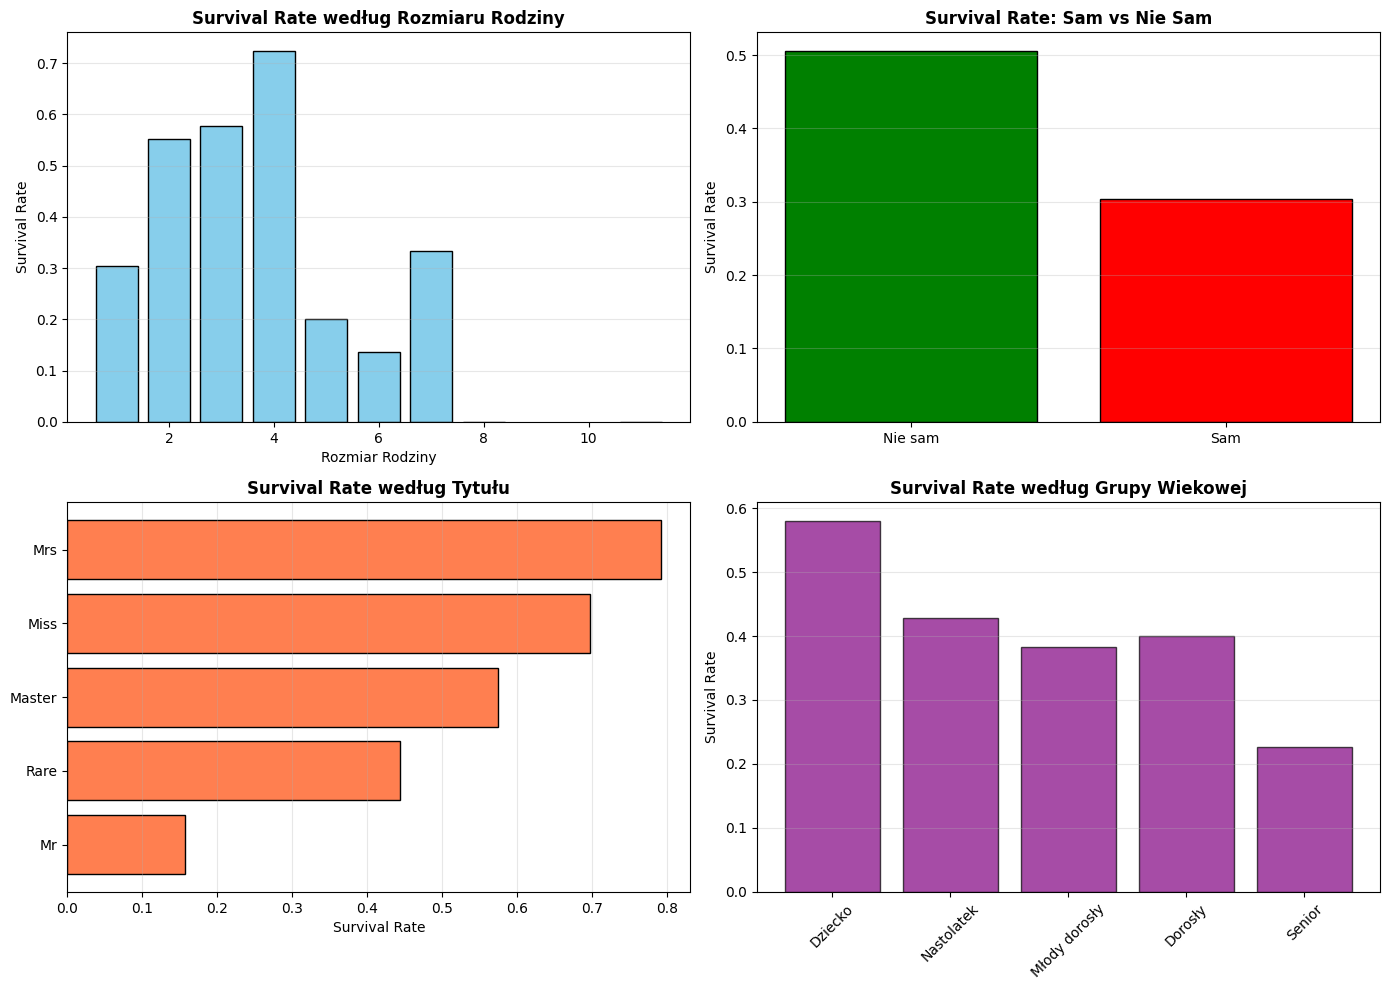

In [36]:
# Wizualizacja: Wpływ Feature Engineering na Survival Rate

# Wizualizacja: Jak nowe cechy wpływają na survival rate
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Family Size
survival_family = titanic_fe.groupby('Family_Size')['Survived'].mean()
axes[0, 0].bar(survival_family.index, survival_family.values, 
color='skyblue', edgecolor='black')
axes[0, 0].set_title('Survival Rate według Rozmiaru Rodziny', fontsize=12, 
fontweight='bold')
axes[0, 0].set_xlabel('Rozmiar Rodziny')
axes[0, 0].set_ylabel('Survival Rate')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Is Alone
survival_alone = titanic_fe.groupby('Is_Alone')['Survived'].mean()
axes[0, 1].bar(['Nie sam', 'Sam'], survival_alone.values, color=['green', 'red'], edgecolor='black')
axes[0, 1].set_title('Survival Rate: Sam vs Nie Sam', fontsize=12, 
fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Title
survival_title = titanic_fe.groupby('Title')['Survived'].mean().sort_values()
axes[1, 0].barh(survival_title.index, survival_title.values, color='coral', 
edgecolor='black')
axes[1, 0].set_title('Survival Rate według Tytułu', fontsize=12, 
fontweight='bold')
axes[1, 0].set_xlabel('Survival Rate')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Age Group
survival_age_group = titanic_fe.groupby('Age_Group', observed=False)['Survived'].mean()
axes[1, 1].bar(range(len(survival_age_group)), survival_age_group.values,
               color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(survival_age_group)))
axes[1, 1].set_xticklabels(survival_age_group.index, rotation=45)
axes[1, 1].set_title('Survival Rate według Grupy Wiekowej', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# WNIOSKI:
# - Tytuł "Mrs" (zamężne kobiety): wysoki survival rate
# - Dzieci: wysoki survival rate ("dzieci najpierw")
# - Małe rodziny (2-4): lepsze szanse niż osoby samotne lub bardzo duże rodziny

# 4. Zaawansowane Operacje Grupowe

In [37]:
# Przykład 1: Custom Funkcje Agregujące

# WŁASNE FUNKCJE AGREGUJĄCE

# Funkcja obliczająca zakres (różnica max - min)
def range_func(x):
    return x.max() - x.min()

# Funkcja obliczająca współczynnik zmienności (CV)
def coef_variation(x):
    return (x.std() / x.mean()) * 100 if x.mean() != 0 else 0

# Funkcja zliczająca outliers (wartości > 2 std od średniej)
def count_outliers(x):
    mean = x.mean()
    std = x.std()
    outliers = ((x < mean - 2*std) | (x > mean + 2*std)).sum()
    return outliers

# Zastosowanie custom funkcji
custom_stats = sales_data.groupby('Region')['Sprzedaż'].agg([
    'mean',
    'std',
    ('zakres', range_func),
    ('CV_%', coef_variation),
    ('outliers_count', count_outliers)
]).round(2)

print("=== Zaawansowane statystyki według regionu ===")
print(custom_stats)

# INTERPRETACJA:
# - CV% (Coefficient of Variation): im wyższy, tym większa zmienność względna
# - Zakres: różnica między max a min sprzedażą
# - Outliers: liczba wartości odstających (>2 std)

=== Zaawansowane statystyki według regionu ===
            mean     std  zakres   CV_%  outliers_count
Region                                                 
Południe  548.76  275.67     868  50.24               0
Północ    564.30  263.67     892  46.73               0
Wschód    595.22  279.46     878  46.95               0
Zachód    595.85  265.04     860  44.48               0


In [38]:
# Przykład 2: Filter - Filtrowanie Grup

# FILTER - wybór tylko tych GRUP, które spełniają warunek

# Wybieramy tylko regiony, w których średnia sprzedaż > 500
high_sales_regions = sales_data.groupby('Region').filter(lambda x: x['Sprzedaż'].mean() > 500)
print(f"Dane przed filtrowaniem grup: {sales_data.shape[0]} wierszy")
print(f"Dane po filtrowaniu grup: {high_sales_regions.shape[0]} wierszy")
print("\n=== Średnia sprzedaż w pozostałych regionach ===")
print(high_sales_regions.groupby('Region')['Sprzedaż'].mean())

# Filter vs Boolean Indexing:
# - Filter usuwa CAŁE GRUPY
# - Boolean indexing usuwa pojedyncze WIERSZE
# Przykład 2: Wybieramy tylko grupy z min. 40 obserwacjami
large_groups = sales_data.groupby('Region').filter(lambda x: len(x) >= 40)

print("\n=== Liczba obserwacji według regionu (tylko duże grupy) ===")
print(large_groups.groupby('Region').size())

Dane przed filtrowaniem grup: 200 wierszy
Dane po filtrowaniu grup: 200 wierszy

=== Średnia sprzedaż w pozostałych regionach ===
Region
Południe    548.760870
Północ      564.304348
Wschód      595.222222
Zachód      595.851852
Name: Sprzedaż, dtype: float64

=== Liczba obserwacji według regionu (tylko duże grupy) ===
Region
Południe    46
Północ      46
Wschód      54
Zachód      54
dtype: int64


In [7]:
# Przykład 3: Apply - Zaawansowane Transformacje Grupowe

# APPLY - elastyczna funkcja, która może zwracać Series, DataFrame lub skalar
# Funkcja normalizująca wartości w grupie do zakresu [0, 1]
def min_max_normalize(group):
    min_val = group['Sprzedaż'].min()
    max_val = group['Sprzedaż'].max()
    group['Sprzedaż_norm'] = (group['Sprzedaż'] - min_val) / (max_val - min_val)
    return group

# Normalizacja wewnątrz każdego regionu
sales_normalized = sales_data.groupby('Region', group_keys=False).apply(min_max_normalize)
print("=== Dane z normalizacją grupową ===")
print(sales_normalized.head(20))

# Weryfikacja: w każdym regionie min=0, max=1
verification = sales_normalized.groupby('Region')['Sprzedaż_norm'].agg(['min', 'max'])

print("\n=== Weryfikacja normalizacji ===")
print(verification)

# ZASTOSOWANIE:
# - Porównanie wyników na różnych skalach
# - Feature scaling dla ML w kontekście grupowym
# - Identyfikacja najlepszych/najgorszych w każdej grupie

=== Dane z normalizacją grupową ===
   Produkt  Sprzedaż  Koszt  Średnia_region  Sprzedaż_norm
0        C       596    317      595.222222       0.545558
1        C       401    372      595.851852       0.324419
2        A       280    114      564.304348       0.197309
3        A       706    466      595.222222       0.670843
4        B       198    217      595.222222       0.092255
5        A       799    379      595.851852       0.787209
6        C       215     92      564.304348       0.124439
7        C       290     93      564.304348       0.208520
8        A       352    334      595.222222       0.267654
9        C       260    446      548.760870       0.167051
10       C       355     61      595.222222       0.271071
11       A       422    144      595.222222       0.347380
12       A       227    351      595.222222       0.125285
13       C       117    435      595.222222       0.000000
14       C       892    302      595.851852       0.895349
15       C       834

KeyError: 'Region'

In [8]:
# Przykład 4: Wykrywanie Outliers Grupowo

# WYKRYWANIE OUTLIERS W KONTEKŚCIE GRUPY
def detect_outliers_iqr(group):
    """Wykrywa outliery metodą IQR (Interquartile Range)"""
    Q1 = group['Sprzedaż'].quantile(0.25)
    Q3 = group['Sprzedaż'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    group['Is_Outlier'] = ((group['Sprzedaż'] < lower_bound) | (group['Sprzedaż'] > upper_bound)).astype(int)
    return group

# Wykrywamy outliery w każdym regionie osobno
sales_outliers = sales_data.groupby('Region', group_keys=False).apply(detect_outliers_iqr)

# Liczba outliers według regionu
outliers_count = sales_outliers.groupby('Region')['Is_Outlier'].sum()
print("=== Liczba outliers według regionu (metoda IQR) ===")
print(outliers_count)

# Pokazujemy przykładowe outliery
print("\n=== Przykładowe outliery ===")
print(sales_outliers[sales_outliers['Is_Outlier'] == 1].head(10))

# ZASTOSOWANIE:
# - Wykrywanie anomalii w kontekście lokalnym (grupa)
# - Wartość może być outlierem w jednym regionie, ale normalna w innym

KeyError: 'Region'

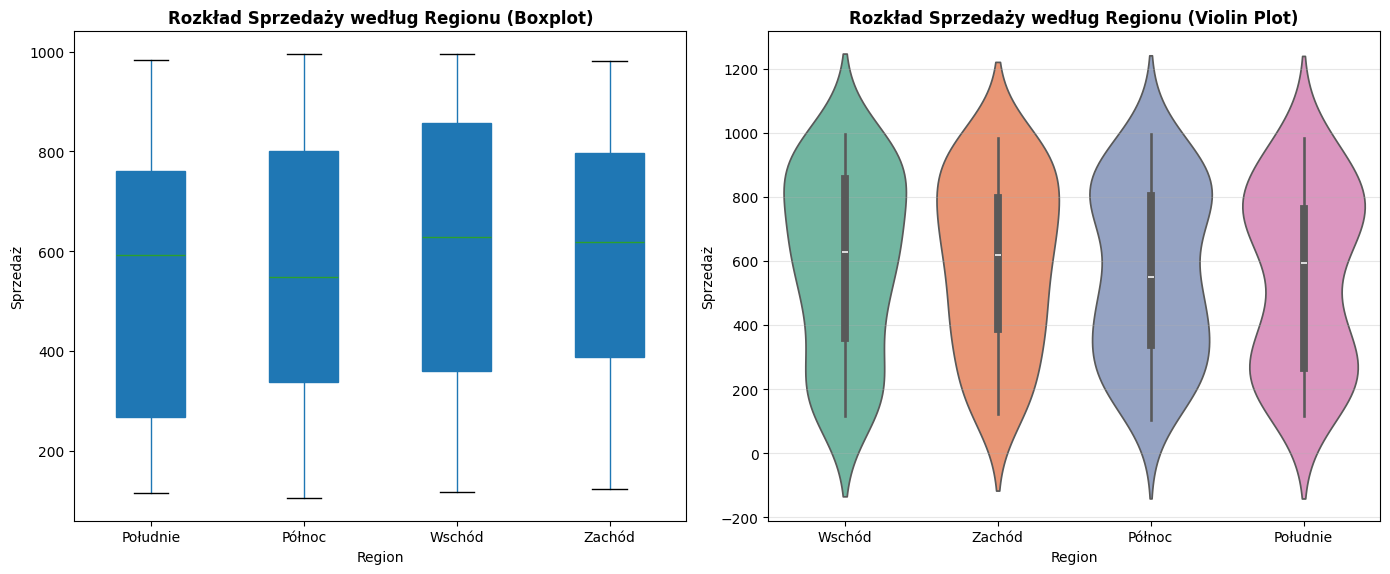

In [45]:
# Wizualizacja: Boxploty Grupowe z Outlierami

# Wizualizacja outliers grupowo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Wykres 1: Boxplot sprzedaży według regionu
sales_data.boxplot(column='Sprzedaż', by='Region', ax=axes[0], grid=False, 
patch_artist=True)
axes[0].set_title('Rozkład Sprzedaży według Regionu (Boxplot)', fontsize=12, 
fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Sprzedaż')
axes[0].get_figure().suptitle('')  # usuwa domyślny tytuł

# Wykres 2: Violin plot - pokazuje pełny rozkład
import seaborn as sns
sns.violinplot(data=sales_data, x='Region', y='Sprzedaż', ax=axes[1], palette='Set2', hue='Region')
axes[1].set_title('Rozkład Sprzedaży według Regionu (Violin Plot)', 
fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Sprzedaż')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# INTERPRETACJA:
# - Boxplot pokazuje medianę, quartiles, outliery
# - Violin plot pokazuje pełny rozkład (density)
# - Różne regiony mają różne rozkłady sprzedaży